In [1]:
# =============================================================================
# SNLI数据集加载与预处理
# =============================================================================
# 自然语言推理(Natural Language Inference, NLI)任务:
# 给定一个前提(premise)和一个假设(hypothesis)，判断两者之间的逻辑关系
#
# 关系类型:
#   - 蕴含(entailment, 标签0): 假设可以从前提中推断出来
#   - 矛盾(contradiction, 标签1): 假设与前提矛盾
#   - 中性(neutral, 标签2): 假设与前提无关，无法确定真假
#
# 示例:
#   前提: "A person on a horse jumps over a broken down airplane."
#   假设: "A person is outdoors, on a horse." -> 蕴含
#   假设: "A person is at a diner, ordering an omelette." -> 矛盾
#   假设: "A person is training his horse for a competition." -> 中性

import os
import re
import torch
import time
from torch import nn
from d2l import torch as d2l
from tqdm import tqdm

# 设置本地数据目录 - 请替换为您的实际路径
DATA_DIR = '../data/snli_1.0'  # SNLI数据集路径

print(f"[初始化] 开始加载SNLI数据集 - {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"[配置] 使用本地数据集路径: {DATA_DIR}")

#@save
def read_snli(data_dir, is_train):
    """
    将SNLI数据集解析为前提、假设和标签

    参数:
        data_dir: 数据集目录路径
        is_train: 是否为训练集(True为训练集，False为测试集)

    返回:
        premises: 前提文本列表
        hypotheses: 假设文本列表
        labels: 标签列表(0=蕴含, 1=矛盾, 2=中性)

    数据处理流程:
        1. 读取tsv格式的数据文件
        2. 清洗文本(去除括号、多余空格等)
        3. 将文本标签转换为数字编码
        4. 统计并输出各类别的样本数量
    """
    print(f"[数据加载] {'训练集' if is_train else '测试集'}读取中...")
    start_time = time.time()

    def extract_text(s):
        """文本清洗函数: 去除括号和多余空格"""
        s = re.sub('\(', '', s)      # 去除左括号
        s = re.sub('\)', '', s)      # 去除右括号
        s = re.sub('\s{2,}', ' ', s)  # 将多个空格替换为单个空格
        return s.strip()

    # 标签映射: 文本标签 -> 数字编码
    label_set = {'entailment': 0, 'contradiction': 1, 'neutral': 2}

    # 根据is_train选择对应的文件
    file_name = os.path.join(data_dir, 'snli_1.0_train.txt' if is_train else 'snli_1.0_test.txt')

    # 添加UTF-8编码支持，如果失败则尝试latin-1编码
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            rows = [row.split('\t') for row in f.readlines()[1:]]  # 跳过表头
    except UnicodeDecodeError:
        print(f"[警告] UTF-8解码失败，尝试使用'latin-1'编码")
        with open(file_name, 'r', encoding='latin-1') as f:
            rows = [row.split('\t') for row in f.readlines()[1:]]

    # 提取前提、假设和标签(只保留有效标签的样本)
    premises = [extract_text(row[1]) for row in rows if row[0] in label_set]
    hypotheses = [extract_text(row[2]) for row in rows if row[0] in label_set]
    labels = [label_set[row[0]] for row in rows if row[0] in label_set]

    # 数据统计: 统计各类别的样本数量
    entailment_count = labels.count(0)
    contradiction_count = labels.count(1)
    neutral_count = labels.count(2)

    print(f"[数据统计] 加载完成! 样本数: {len(premises):,}")
    print(f"  蕴含(entailment): {entailment_count:,} | 矛盾(contradiction): {contradiction_count:,} | 中性(neutral): {neutral_count:,}")
    print(f"[计时] 数据加载耗时: {time.time() - start_time:.2f}秒")

    return premises, hypotheses, labels

# =============================================================================
# 加载训练集和测试集
# =============================================================================
print("\n" + "="*50)
print("加载训练集数据...")
train_data = read_snli(DATA_DIR, is_train=True)
print("\n加载测试集数据...")
test_data = read_snli(DATA_DIR, is_train=False)
print("="*50)

# 打印示例数据，帮助理解数据格式
print("\n[数据示例] 前三组训练样本:")
for i, (x0, x1, y) in enumerate(zip(train_data[0][:3], train_data[1][:3], train_data[2][:3])):
    print(f"\n示例 {i+1}:")
    print(f"  前提: {x0}")
    print(f"  假设: {x1}")
    print(f"  标签: {y} ({'蕴含' if y == 0 else '矛盾' if y == 1 else '中性'})")

#@save
class SNLIDataset(torch.utils.data.Dataset):
    """
    用于加载SNLI数据集的自定义数据集类

    功能:
        1. 对文本进行分词处理
        2. 构建词汇表(训练集创建，测试集复用)
        3. 将文本转换为token索引序列
        4. 对序列进行填充/截断，使其长度统一

    属性:
        num_steps: 序列最大长度(统一填充到此长度)
        vocab: 词汇表对象
        premises: 前提序列张量，形状为(num_samples, num_steps)
        hypotheses: 假设序列张量，形状为(num_samples, num_steps)
        labels: 标签张量，形状为(num_samples,)
    """

    def __init__(self, dataset, num_steps, vocab=None):
        """
        初始化SNLI数据集

        参数:
            dataset: 包含(premises, hypotheses, labels)的元组
            num_steps: 序列最大长度
            vocab: 词汇表对象(训练集时为None，会创建新词汇表；测试集时传入训练集的词汇表)
        """
        print(f"\n[数据集] 创建SNLI数据集 (序列长度={num_steps})")
        start_time = time.time()
        self.num_steps = num_steps

        # 分词处理: 将文本字符串分割为token列表
        print("[分词] 处理前提文本...")
        all_premise_tokens = d2l.tokenize(dataset[0])  # 对前提文本分词
        print("[分词] 处理假设文本...")
        all_hypothesis_tokens = d2l.tokenize(dataset[1])  # 对假设文本分词

        # 创建或复用词汇表
        if vocab is None:
            # 训练集: 创建新词汇表
            print("[词汇表] 创建新词汇表...")
            # min_freq=5: 只保留出现频率>=5的token
            # reserved_tokens=['<pad>']: 保留填充token
            self.vocab = d2l.Vocab(all_premise_tokens + all_hypothesis_tokens,
                                  min_freq=5, reserved_tokens=['<pad>'])
            print(f"[词汇表] 词汇表大小: {len(self.vocab)}")
        else:
            # 测试集: 复用训练集的词汇表，确保一致性
            print(f"[词汇表] 使用现有词汇表 (大小={len(vocab)})")
            self.vocab = vocab

        # 填充序列: 将变长序列转换为固定长度的张量
        print("[填充] 处理前提序列...")
        self.premises = self._pad(all_premise_tokens)
        print("[填充] 处理假设序列...")
        self.hypotheses = self._pad(all_hypothesis_tokens)

        # 将标签转换为张量
        self.labels = torch.tensor(dataset[2])
        print(f"[数据集] 创建完成! 样本数: {len(self.premises):,}")
        print(f"[计时] 数据集创建耗时: {time.time() - start_time:.2f}秒")

    def _pad(self, lines):
        """
        将token列表填充/截断为固定长度的序列

        参数:
            lines: token列表的列表

        返回:
            形状为(num_samples, num_steps)的张量

        处理逻辑:
            - 如果序列长度 > num_steps: 截断到num_steps
            - 如果序列长度 < num_steps: 用<pad>填充到num_steps
        """
        return torch.tensor([d2l.truncate_pad(
            self.vocab[line], self.num_steps, self.vocab['<pad>'])
                         for line in lines])

    def __getitem__(self, idx):
        """
        获取指定索引的样本

        返回:
            ((premise, hypothesis), label): 前提、假设和标签的元组
        """
        return (self.premises[idx], self.hypotheses[idx]), self.labels[idx]

    def __len__(self):
        """返回数据集样本总数"""
        return len(self.premises)

#@save
def load_data_snli(batch_size, num_steps=50):
    """
    加载SNLI数据集并返回数据迭代器和词汇表

    参数:
        batch_size: 批次大小
        num_steps: 序列最大长度

    返回:
        train_iter: 训练集数据迭代器
        test_iter: 测试集数据迭代器
        vocab: 词汇表对象

    使用示例:
        >>> train_iter, test_iter, vocab = load_data_snli(128, 50)
        >>> for (premises, hypotheses), labels in train_iter:
        ...     # 训练代码
    """
    print("\n" + "="*50)
    print(f"准备数据迭代器 (批大小={batch_size}, 序列长度={num_steps})")
    start_time = time.time()

    # 设置工作进程数(Windows环境下建议设为0避免多进程问题)
    num_workers = 0
    print(f"[配置] 使用 {num_workers} 个工作进程")

    # 创建训练集和测试集
    print("\n[训练集] 创建数据集...")
    train_set = SNLIDataset(train_data, num_steps)
    print("\n[测试集] 创建数据集...")
    test_set = SNLIDataset(test_data, num_steps, train_set.vocab)

    # 创建数据加载器
    print("\n[数据加载器] 创建训练集迭代器...")
    train_iter = torch.utils.data.DataLoader(train_set, batch_size,
                                             shuffle=True,      # 训练集打乱顺序
                                             num_workers=num_workers)

    print("[数据加载器] 创建测试集迭代器...")
    test_iter = torch.utils.data.DataLoader(test_set, batch_size,
                                            shuffle=False,     # 测试集不打乱
                                            num_workers=num_workers)

    print(f"[完成] 数据加载器创建完成! 总耗时: {time.time() - start_time:.2f}秒")
    print("="*50)

    return train_iter, test_iter, train_set.vocab

# =============================================================================
# 主程序: 数据加载与验证
# =============================================================================
if __name__ == "__main__":
    # 设置超参数
    BATCH_SIZE = 128    # 批次大小
    SEQ_LENGTH = 50     # 序列最大长度

    print(f"\n{'='*50}")
    print(f"开始主程序 (批大小={BATCH_SIZE}, 序列长度={SEQ_LENGTH})")
    print(f"{'='*50}\n")

    # 加载数据
    train_iter, test_iter, vocab = load_data_snli(BATCH_SIZE, SEQ_LENGTH)

    # 打印词汇表信息
    print(f"\n[词汇表] 最终词汇表大小: {len(vocab)}")
    print(f"  特殊词元: <pad> -> {vocab['<pad>']}")

    # 检查第一批数据
    print("\n[数据检查] 第一批数据形状:")
    batch = next(iter(train_iter))
    (premises, hypotheses), labels = batch

    # 打印张量形状
    # premises: (batch_size, num_steps) - 前提序列
    # hypotheses: (batch_size, num_steps) - 假设序列
    # labels: (batch_size,) - 标签
    print(f"  前提张量形状: {premises.shape}")  # (batch_size, num_steps)
    print(f"  假设张量形状: {hypotheses.shape}")  # (batch_size, num_steps)
    print(f"  标签张量形状: {labels.shape}")     # (batch_size,)

    # 打印第一个样本的内容
    sample_idx = 0
    print(f"\n[样本分析] 第一个样本 (索引={sample_idx}):")
    print(f"  前提ID: {premises[sample_idx].tolist()[:10]}... (长度: {len(premises[sample_idx])})")
    print(f"  假设ID: {hypotheses[sample_idx].tolist()[:10]}... (长度: {len(hypotheses[sample_idx])})")
    print(f"  标签: {labels[sample_idx].item()} ({'蕴含' if labels[sample_idx] == 0 else '矛盾' if labels[sample_idx] == 1 else '中性'})")

    print("\n[完成] 数据处理流程结束!")


[初始化] 开始加载SNLI数据集 - 2025-06-01 01:18:59
[配置] 使用本地数据集路径: ../data/snli_1.0

加载训练集数据...
[数据加载] 训练集读取中...
[数据统计] 加载完成! 样本数: 549,367
  蕴含(entailment): 183,416 | 矛盾(contradiction): 183,187 | 中性(neutral): 182,764
[计时] 数据加载耗时: 6.68秒

加载测试集数据...
[数据加载] 测试集读取中...
[数据统计] 加载完成! 样本数: 9,824
  蕴含(entailment): 3,368 | 矛盾(contradiction): 3,237 | 中性(neutral): 3,219
[计时] 数据加载耗时: 0.14秒

[数据示例] 前三组训练样本:

示例 1:
  前提: A person on a horse jumps over a broken down airplane .
  假设: A person is training his horse for a competition .
  标签: 2 (中性)

示例 2:
  前提: A person on a horse jumps over a broken down airplane .
  假设: A person is at a diner , ordering an omelette .
  标签: 1 (矛盾)

示例 3:
  前提: A person on a horse jumps over a broken down airplane .
  假设: A person is outdoors , on a horse .
  标签: 0 (蕴含)

开始主程序 (批大小=128, 序列长度=50)


准备数据迭代器 (批大小=128, 序列长度=50)
[配置] 使用 0 个工作进程

[训练集] 创建数据集...

[数据集] 创建SNLI数据集 (序列长度=50)
[分词] 处理前提文本...
[分词] 处理假设文本...
[词汇表] 创建新词汇表...
[词汇表] 词汇表大小: 18678
[填充] 处理前提序列...
[填充] 处理假设序列...
[数据集] 

KeyboardInterrupt: 

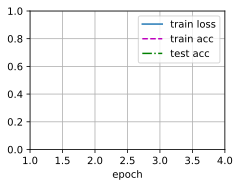

In [3]:
# =============================================================================
# 可分解注意力模型 (Decomposable Attention Model)
# =============================================================================
# 本单元实现基于Decomposable Attention的自然语言推理模型
#
# 模型架构概述:
#   可分解注意力模型由三个主要模块组成:
#   1. Attend模块: 计算前提和假设之间的软对齐(soft alignment)
#   2. Compare模块: 比较对齐后的表示
#   3. Aggregate模块: 聚合比较结果并输出最终预测
#
# 模型特点:
#   - 使用注意力机制进行软对齐，而非传统的硬对齐
#   - 计算复杂度为O(m*n)，其中m和n分别是前提和假设的长度
#   - 相比LSTM-based模型，计算效率更高
#
# 参考文献: "A Decomposable Attention Model for Natural Language Inference" (Parikh et al., 2016)

import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

# =============================================================================
# MLP辅助函数
# =============================================================================
def mlp(num_inputs, num_hiddens, flatten):
    """
    创建多层感知机(MLP)

    参数:
        num_inputs: 输入特征维度
        num_hiddens: 隐藏层维度
        flatten: 是否在第一层后添加Flatten层

    返回:
        包含两个全连接层的MLP网络

    网络结构:
        - Dropout(0.2) -> Linear(num_inputs, num_hiddens) -> ReLU
        - [可选] Flatten(start_dim=1)
        - Dropout(0.2) -> Linear(num_hiddens, num_hiddens) -> ReLU
        - [可选] Flatten(start_dim=1)
    """
    net = []
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)

# =============================================================================
# Attend模块: 软对齐
# =============================================================================
class Attend(nn.Module):
    """
    注意力模块: 计算前提和假设之间的软对齐

    原理:
        通过计算两个序列中每对词元之间的注意力分数，实现软对齐。
        软对齐意味着假设中的每个词元都可以"关注"前提中的所有词元，
        反之亦然，关注程度由注意力权重决定。

    数学公式:
        1. 首先将输入通过MLP进行特征提取:
           f_A = f(A), f_B = f(B)
           其中f是共享的MLP，A和B分别是前提和假设的嵌入表示

        2. 计算注意力分数矩阵:
           e = f_A @ f_B^T
           e的形状为(batch_size, m, n)，其中m是前提长度，n是假设长度

        3. 计算软对齐表示:
           beta = softmax(e, dim=-1) @ B  (假设对齐到前提)
           alpha = softmax(e^T, dim=-1) @ A  (前提对齐到假设)
    """

    def __init__(self, num_inputs, num_hiddens, **kwargs):
        """
        初始化Attend模块

        参数:
            num_inputs: 输入嵌入维度(如GloVe词嵌入维度)
            num_hiddens: 注意力机制中的隐藏层维度
        """
        super(Attend, self).__init__(**kwargs)
        # f是共享的MLP，用于将词嵌入映射到注意力空间
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        """
        前向传播: 计算软对齐

        参数:
            A: 前提的嵌入表示，形状为(batch_size, m, embed_size)
            B: 假设的嵌入表示，形状为(batch_size, n, embed_size)

        返回:
            beta: 假设对齐到前提的表示，形状为(batch_size, m, embed_size)
            alpha: 前提对齐到假设的表示，形状为(batch_size, n, embed_size)

        维度说明:
            - A/B输入形状: (batch_size, seq_len, embed_size)
            - f_A/f_B形状: (batch_size, seq_len, num_hiddens)
            - e注意力分数形状: (batch_size, m, n)
            - beta形状: (batch_size, m, embed_size) - 假设的加权平均
            - alpha形状: (batch_size, n, embed_size) - 前提的加权平均
        """
        # 通过MLP提取特征
        # f_A形状: (batch_size, m, num_hiddens)
        f_A = self.f(A)
        # f_B形状: (batch_size, n, num_hiddens)
        f_B = self.f(B)

        # 计算注意力分数矩阵
        # e[i,j]表示前提中第i个词元与假设中第j个词元的相似度
        # e形状: (batch_size, m, n)
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))

        # 计算软对齐表示
        # beta: 对假设B进行加权平均，权重由前提A决定
        # 即对于前提中的每个位置，计算假设中所有位置的加权平均
        # beta形状: (batch_size, m, embed_size)
        beta = torch.bmm(F.softmax(e, dim=-1), B)

        # alpha: 对前提A进行加权平均，权重由假设B决定
        # e.permute(0, 2, 1)形状: (batch_size, n, m)
        # alpha形状: (batch_size, n, embed_size)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)

        return beta, alpha

# =============================================================================
# Compare模块: 比较对齐后的表示
# =============================================================================
class Compare(nn.Module):
    """
    比较模块: 比较原始表示与对齐后的表示

    原理:
        对于前提中的每个位置，比较原始词嵌入与其对齐的假设表示;
        对于假设中的每个位置，比较原始词嵌入与其对齐的前提表示。
        比较通过拼接后输入MLP实现。

    数学公式:
        V_A = g([A; beta])  # 比较前提与对齐的假设
        V_B = g([B; alpha])  # 比较假设与对齐的前提
        其中[;]表示拼接操作，g是共享的MLP
    """

    def __init__(self, num_inputs, num_hiddens, **kwargs):
        """
        初始化Compare模块

        参数:
            num_inputs: 输入维度(2 * embed_size，因为是拼接操作)
            num_hiddens: 比较MLP的隐藏层维度
        """
        super(Compare, self).__init__(**kwargs)
        # g是共享的MLP，用于比较原始表示和对齐表示
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        """
        前向传播: 比较对齐表示

        参数:
            A: 前提的原始嵌入，形状为(batch_size, m, embed_size)
            B: 假设的原始嵌入，形状为(batch_size, n, embed_size)
            beta: 假设对齐到前提的表示，形状为(batch_size, m, embed_size)
            alpha: 前提对齐到假设的表示，形状为(batch_size, n, embed_size)

        返回:
            V_A: 前提的比较结果，形状为(batch_size, m, num_hiddens)
            V_B: 假设的比较结果，形状为(batch_size, n, num_hiddens)

        维度说明:
            - torch.cat([A, beta], dim=2)形状: (batch_size, m, 2*embed_size)
            - V_A形状: (batch_size, m, num_hiddens)
            - V_B形状: (batch_size, n, num_hiddens)
        """
        # 比较前提与其对齐的假设表示
        # 在最后一个维度拼接，将原始嵌入和对齐表示组合
        V_A = self.g(torch.cat([A, beta], dim=2))

        # 比较假设与其对齐的前提表示
        V_B = self.g(torch.cat([B, alpha], dim=2))

        return V_A, V_B

# =============================================================================
# Aggregate模块: 聚合比较结果
# =============================================================================
class Aggregate(nn.Module):
    """
    聚合模块: 聚合比较结果并输出最终预测

    原理:
        1. 对比较结果进行求和聚合(将序列维度的信息聚合为单个向量)
        2. 将前提和假设的聚合结果拼接
        3. 通过MLP和线性层输出最终的分类 logits

    数学公式:
        v_A = sum(V_A, dim=1)  # 对前提的比较结果求和
        v_B = sum(V_B, dim=1)  # 对假设的比较结果求和
        Y_hat = Linear(h([v_A; v_B]))  # 拼接后通过MLP和线性层
    """

    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        """
        初始化Aggregate模块

        参数:
            num_inputs: 输入维度(2 * num_hiddens，因为是拼接后的维度)
            num_hiddens: 聚合MLP的隐藏层维度
            num_outputs: 输出类别数(对于SNLI是3: 蕴含/矛盾/中性)
        """
        super(Aggregate, self).__init__(**kwargs)
        # h是聚合MLP，将拼接后的表示映射到隐藏空间
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        # 最终线性分类器，输出3个类别的logits
        self.linear = nn.Linear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        """
        前向传播: 聚合并分类

        参数:
            V_A: 前提的比较结果，形状为(batch_size, m, num_hiddens)
            V_B: 假设的比较结果，形状为(batch_size, n, num_hiddens)

        返回:
            Y_hat: 分类logits，形状为(batch_size, num_outputs)

        维度说明:
            - V_A.sum(dim=1)形状: (batch_size, num_hiddens)
            - V_B.sum(dim=1)形状: (batch_size, num_hiddens)
            - torch.cat([...], dim=1)形状: (batch_size, 2*num_hiddens)
            - Y_hat形状: (batch_size, num_outputs)
        """
        # 对比较结果进行求和聚合
        # 将序列维度的信息聚合为单个向量表示
        V_A = V_A.sum(dim=1)  # 形状: (batch_size, num_hiddens)
        V_B = V_B.sum(dim=1)  # 形状: (batch_size, num_hiddens)

        # 拼接前提和假设的聚合表示，通过MLP和线性层输出预测
        # 输出形状: (batch_size, num_outputs)，num_outputs=3
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat

# =============================================================================
# DecomposableAttention: 完整的可分解注意力模型
# =============================================================================
class DecomposableAttention(nn.Module):
    """
    可分解注意力模型: 完整的NLI模型

    模型流程:
        1. 词嵌入: 将token索引转换为词嵌入向量
        2. Attend: 计算前提和假设之间的软对齐
        3. Compare: 比较原始表示与对齐表示
        4. Aggregate: 聚合比较结果并输出分类

    参数说明:
        - num_inputs_attend=100: Attend模块输入维度(等于embed_size)
        - num_inputs_compare=200: Compare模块输入维度(等于2*embed_size)
        - num_inputs_agg=400: Aggregate模块输入维度(等于2*num_hiddens)
    """

    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        """
        初始化可分解注意力模型

        参数:
            vocab: 词汇表对象
            embed_size: 词嵌入维度
            num_hiddens: 隐藏层维度
            num_inputs_attend: Attend模块输入维度
            num_inputs_compare: Compare模块输入维度
            num_inputs_agg: Aggregate模块输入维度
        """
        super(DecomposableAttention, self).__init__(**kwargs)
        # 词嵌入层: 将token索引映射为密集向量
        self.embedding = nn.Embedding(len(vocab), embed_size)

        # 三个核心模块
        self.attend = Attend(num_inputs_attend, num_hiddens)      # 软对齐
        self.compare = Compare(num_inputs_compare, num_hiddens)   # 比较
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)  # 聚合

    def forward(self, X):
        """
        前向传播

        参数:
            X: 包含(premises, hypotheses)的元组
               - premises: 前提token索引，形状为(batch_size, m)
               - hypotheses: 假设token索引，形状为(batch_size, n)

        返回:
            Y_hat: 分类logits，形状为(batch_size, 3)

        完整流程:
            1. premises -> embedding -> A (batch_size, m, embed_size)
            2. hypotheses -> embedding -> B (batch_size, n, embed_size)
            3. attend(A, B) -> beta, alpha
            4. compare(A, B, beta, alpha) -> V_A, V_B
            5. aggregate(V_A, V_B) -> Y_hat
        """
        premises, hypotheses = X

        # 词嵌入: 将token索引转换为密集向量
        A = self.embedding(premises)      # 形状: (batch_size, m, embed_size)
        B = self.embedding(hypotheses)    # 形状: (batch_size, n, embed_size)

        # Attend: 计算软对齐
        beta, alpha = self.attend(A, B)

        # Compare: 比较原始表示与对齐表示
        V_A, V_B = self.compare(A, B, beta, alpha)

        # Aggregate: 聚合并分类
        Y_hat = self.aggregate(V_A, V_B)

        return Y_hat

# =============================================================================
# 数据加载
# =============================================================================
# 加载SNLI数据集
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

# =============================================================================
# 模型初始化
# =============================================================================
# 设置超参数
embed_size, num_hiddens, devices = 100, 200, d2l.try_all_gpus()

# 创建模型
net = DecomposableAttention(vocab, embed_size, num_hiddens)

# 加载GloVe预训练词嵌入
glove_embedding = d2l.TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]

# 将预训练词嵌入复制到模型的嵌入层
net.embedding.weight.data.copy_(embeds)

# =============================================================================
# 训练配置
# =============================================================================
lr, num_epochs = 0.001, 4  # 学习率和训练轮数

# 创建优化器(Adam)
trainer = torch.optim.Adam(net.parameters(), lr=lr)

# 定义损失函数(交叉熵损失)
loss = nn.CrossEntropyLoss(reduction="none")

# 使用d2l的训练函数进行训练
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)


In [ ]:
# =============================================================================
# 预测函数: 使用训练好的模型进行推理
# =============================================================================
# 本单元实现使用训练好的可分解注意力模型进行自然语言推理预测
#
# 功能:
#   - 将输入的前提和假设文本转换为模型可处理的格式
#   - 使用训练好的模型进行前向传播
#   - 返回预测的逻辑关系类别

import torch
from d2l import torch as d2l

#@save
def predict_snli(net, vocab, premise, hypothesis):
    """
    预测前提和假设之间的逻辑关系

    参数:
        net: 训练好的DecomposableAttention模型
        vocab: 词汇表对象，用于将token转换为索引
        premise: 前提文本的token列表，如 ['he', 'is', 'good', '.']
        hypothesis: 假设文本的token列表，如 ['he', 'is', 'bad', '.']

    返回:
        预测的关系类别字符串:
            - 'entailment': 蕴含关系
            - 'contradiction': 矛盾关系
            - 'neutral': 中性关系

    处理流程:
        1. 将模型设置为评估模式(net.eval())
        2. 将token列表转换为词汇表索引
        3. 将索引张量移动到GPU(如果可用)
        4. 调整张量形状为(batch_size=1, seq_len)
        5. 前向传播获取预测logits
        6. 取argmax获取预测类别
        7. 将数字标签转换为文本标签

    使用示例:
        >>> premise = ['he', 'is', 'good', '.']
        >>> hypothesis = ['he', 'is', 'bad', '.']
        >>> result = predict_snli(net, vocab, premise, hypothesis)
        >>> print(result)  # 输出: 'contradiction'
    """
    # 将模型设置为评估模式
    # 这会禁用dropout等训练时特有的行为，确保推理结果的一致性
    net.eval()

    # 将token列表转换为词汇表索引
    # vocab[premise]返回一个包含索引的列表
    premise_tensor = torch.tensor(vocab[premise], device=d2l.try_gpu())
    hypothesis_tensor = torch.tensor(vocab[hypothesis], device=d2l.try_gpu())

    # 调整张量形状为(batch_size=1, seq_len)
    # 模型期望的输入形状是(batch_size, seq_len)，因此需要添加batch维度
    premise_batch = premise_tensor.reshape((1, -1))
    hypothesis_batch = hypothesis_tensor.reshape((1, -1))

    # 前向传播获取预测结果
    # net([premise_batch, hypothesis_batch])返回形状为(1, 3)的logits
    with torch.no_grad():  # 推理时不需要计算梯度，节省内存
        logits = net([premise_batch, hypothesis_batch])

    # 取argmax获取预测类别
    # label是一个标量张量，值为0、1或2
    label = torch.argmax(logits, dim=1)

    # 将数字标签转换为文本标签
    # 0 -> 'entailment' (蕴含)
    # 1 -> 'contradiction' (矛盾)
    # 2 -> 'neutral' (中性)
    if label == 0:
        return 'entailment'
    elif label == 1:
        return 'contradiction'
    else:
        return 'neutral'


# =============================================================================
# 预测示例
# =============================================================================
# 示例1: 矛盾关系
# 前提: "he is good." (他是好人)
# 假设: "he is bad." (他是坏人)
# 预期输出: 'contradiction' (矛盾)
result1 = predict_snli(net, vocab, ['he', 'is', 'good', '.'], ['he', 'is', 'bad', '.'])
print(f"示例1 - 前提: 'he is good.', 假设: 'he is bad.'")
print(f"预测结果: {result1}")
print()

# 可以添加更多测试示例
# 示例2: 蕴含关系
# result2 = predict_snli(net, vocab, ['a', 'man', 'is', 'running', '.'], ['a', 'person', 'is', 'moving', '.'])
# print(f"示例2 - 预测结果: {result2}")  # 预期: 'entailment'

# 示例3: 中性关系
# result3 = predict_snli(net, vocab, ['a', 'person', 'is', 'on', 'a', 'horse', '.'], ['the', 'person', 'is', 'training', 'the', 'horse', '.'])
# print(f"示例3 - 预测结果: {result3}")  # 预期: 'neutral'


In [2]:
# =============================================================================
# 可分解注意力模型训练 (优化版本)
# =============================================================================
# 本单元实现带有详细进度跟踪的训练流程
#
# 特点:
#   - 使用tqdm显示训练进度条
#   - 记录详细的训练指标(损失、准确率、时间等)
#   - 支持多GPU训练(DataParallel)
#   - 使用GloVe预训练词嵌入并冻结
#
# 训练流程:
#   1. 数据加载与预处理
#   2. 模型构建与初始化
#   3. 加载预训练词嵌入
#   4. 自定义训练循环(带进度跟踪)
#   5. 模型评估与保存

import torch
import time
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
from tqdm import tqdm
import numpy as np

# 打印训练日志头部
print("="*80)
print(f"可分解注意力模型训练 - {time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# =============================================================================
# MLP辅助函数
# =============================================================================
def mlp(num_inputs, num_hiddens, flatten):
    """
    创建多层感知机(MLP)

    参数:
        num_inputs: 输入特征维度
        num_hiddens: 隐藏层维度
        flatten: 是否在第一层后添加Flatten层

    返回:
        包含两个全连接层的MLP网络
    """
    net = []
    net.append(nn.Dropout(0.2))           # Dropout防止过拟合
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())                 # ReLU激活函数
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)

# =============================================================================
# Attend模块: 软对齐
# =============================================================================
class Attend(nn.Module):
    """
    注意力模块: 计算前提和假设之间的软对齐

    通过计算两个序列中每对词元之间的注意力分数，实现软对齐。
    """
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Attend, self).__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        """
        参数:
            A: 前提嵌入，形状(batch_size, m, embed_size)
            B: 假设嵌入，形状(batch_size, n, embed_size)
        返回:
            beta: 假设对齐到前提，形状(batch_size, m, embed_size)
            alpha: 前提对齐到假设，形状(batch_size, n, embed_size)
        """
        f_A = self.f(A)  # (batch_size, m, num_hiddens)
        f_B = self.f(B)  # (batch_size, n, num_hiddens)
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))  # (batch_size, m, n)
        beta = torch.bmm(F.softmax(e, dim=-1), B)  # (batch_size, m, embed_size)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)  # (batch_size, n, embed_size)
        return beta, alpha

# =============================================================================
# Compare模块: 比较对齐后的表示
# =============================================================================
class Compare(nn.Module):
    """比较模块: 比较原始表示与对齐后的表示"""
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Compare, self).__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        """
        参数:
            A: 前提原始嵌入
            B: 假设原始嵌入
            beta: 假设对齐到前提的表示
            alpha: 前提对齐到假设的表示
        返回:
            V_A, V_B: 比较结果
        """
        V_A = self.g(torch.cat([A, beta], dim=2))
        V_B = self.g(torch.cat([B, alpha], dim=2))
        return V_A, V_B

# =============================================================================
# Aggregate模块: 聚合比较结果
# =============================================================================
class Aggregate(nn.Module):
    """聚合模块: 聚合比较结果并输出最终预测"""
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super(Aggregate, self).__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = nn.Linear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        """
        参数:
            V_A: 前提的比较结果
            V_B: 假设的比较结果
        返回:
            Y_hat: 分类logits，形状(batch_size, num_outputs)
        """
        V_A = V_A.sum(dim=1)  # (batch_size, num_hiddens)
        V_B = V_B.sum(dim=1)  # (batch_size, num_hiddens)
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat

# =============================================================================
# DecomposableAttention: 完整的可分解注意力模型
# =============================================================================
class DecomposableAttention(nn.Module):
    """可分解注意力模型: 完整的NLI模型"""
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super(DecomposableAttention, self).__init__(**kwargs)
        print("\n" + "="*80)
        print(f"[模型] 初始化可分解注意力模型")
        print(f"  词汇表大小: {len(vocab)}")
        print(f"  嵌入维度: {embed_size}")
        print(f"  隐藏层维度: {num_hiddens}")
        print("="*80 + "\n")

        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)

    def forward(self, X):
        """前向传播"""
        premises, hypotheses = X
        A = self.embedding(premises)      # (batch_size, m, embed_size)
        B = self.embedding(hypotheses)    # (batch_size, n, embed_size)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        Y_hat = self.aggregate(V_A, V_B)
        return Y_hat

# =============================================================================
# 数据加载
# =============================================================================
print("\n[数据] 加载SNLI数据集...")
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)
print(f"[数据] 加载完成! 词汇表大小: {len(vocab)}")

# =============================================================================
# 模型初始化
# =============================================================================
print("\n[配置] 初始化模型参数...")
embed_size, num_hiddens = 100, 200
devices = d2l.try_all_gpus()
print(f"[设备] 可用设备: {devices}")

# 创建模型
print("\n[模型] 创建模型...")
net = DecomposableAttention(vocab, embed_size, num_hiddens)

# =============================================================================
# 加载预训练词嵌入
# =============================================================================
print("\n[嵌入] 加载GloVe预训练词向量...")
glove_embedding = d2l.TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
print(f"[嵌入] 预训练嵌入形状: {embeds.shape}")

# 复制预训练词嵌入到模型
print("[嵌入] 复制预训练词嵌入到模型...")
net.embedding.weight.data.copy_(embeds)
# 冻结词嵌入权重(不训练)
net.embedding.weight.requires_grad = False
print("[嵌入] 词嵌入权重已冻结(不参与训练)")

# =============================================================================
# 训练配置
# =============================================================================
lr, num_epochs = 0.001, 4
print(f"\n[训练] 配置训练参数:")
print(f"  学习率: {lr}")
print(f"  训练轮数: {num_epochs}")

# 创建优化器和损失函数
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
print(f"[优化器] 使用Adam优化器")
print(f"[损失函数] 使用交叉熵损失")

# 将模型移动到设备并启用DataParallel
net = nn.DataParallel(net, device_ids=devices).to(devices[0])
print(f"[设备] 模型已移动到 {devices}")

# =============================================================================
# 自定义训练函数 (带进度跟踪)
# =============================================================================
def train_with_progress(net, train_iter, test_iter, loss, trainer, num_epochs, devices):
    """
    带进度跟踪的训练函数

    参数:
        net: 神经网络模型
        train_iter: 训练数据迭代器
        test_iter: 测试数据迭代器
        loss: 损失函数
        trainer: 优化器
        num_epochs: 训练轮数
        devices: 训练设备列表

    功能:
        - 使用tqdm显示训练进度条
        - 每10个批次更新一次指标显示
        - 记录训练历史(损失、准确率、时间)
        - 每轮结束后评估测试集
    """
    print("\n" + "="*80)
    print(f"开始训练 (共 {num_epochs} 轮)")
    print("="*80)

    # 记录训练历史
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'epoch_time': [],
        'batch_times': []
    }

    # 训练循环
    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\n[Epoch {epoch+1}/{num_epochs}]")

        # 设置模型为训练模式
        net.train()
        # Accumulator用于累积指标: (损失总和, 正确预测数, 总样本数)
        metric = d2l.Accumulator(3)

        # 获取批次数量
        train_batches = len(train_iter)
        batch_times = []

        # 使用tqdm创建进度条
        with tqdm(total=train_batches, desc=f"训练轮次 {epoch+1}", unit="batch") as pbar:
            for i, batch in enumerate(train_iter):
                batch_start = time.time()

                # 解构批次数据
                (premises, hypotheses), labels = batch

                # 将数据移动到设备(GPU)
                premises = premises.to(devices[0])
                hypotheses = hypotheses.to(devices[0])
                labels = labels.to(devices[0])

                # 前向传播和反向传播
                trainer.zero_grad()           # 清空梯度
                y_hat = net((premises, hypotheses))  # 前向传播
                l = loss(y_hat, labels)       # 计算损失
                l.mean().backward()           # 反向传播
                trainer.step()                # 更新参数

                # 计算指标
                with torch.no_grad():
                    # 累积: 损失总和, 正确预测数, 总样本数
                    metric.add(float(l.sum()), d2l.accuracy(y_hat, labels), labels.numel())

                # 记录批次时间
                batch_time = time.time() - batch_start
                batch_times.append(batch_time)

                # 每10个批次更新进度条显示
                if i % 10 == 0 or i == train_batches - 1:
                    train_loss = metric[0] / metric[2]  # 平均损失
                    train_acc = metric[1] / metric[2]   # 平均准确率
                    # 计算最近10个批次的平均时间
                    avg_batch_time = np.mean(batch_times[-10:]) * 1000 if batch_times else 0

                    # 更新进度条后缀信息
                    pbar.set_postfix({
                        'loss': f'{train_loss:.4f}',
                        'acc': f'{train_acc:.3f}',
                        'batch': f'{avg_batch_time:.1f}ms'
                    })

                pbar.update(1)

        # 记录训练指标
        epoch_train_loss = metric[0] / metric[2]
        epoch_train_acc = metric[1] / metric[2]
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # 评估测试集
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        history['test_acc'].append(test_acc)

        # 记录本轮时间
        epoch_time = time.time() - epoch_start
        history['epoch_time'].append(epoch_time)

        # 打印本轮总结
        print(f"\n[Epoch {epoch+1} 完成]")
        print(f"  训练损失: {epoch_train_loss:.4f}")
        print(f"  训练准确率: {epoch_train_acc:.3f}")
        print(f"  测试准确率: {test_acc:.3f}")
        print(f"  耗时: {epoch_time:.2f}秒")

    # 训练完成总结
    print("\n" + "="*80)
    print("训练完成!")
    print("="*80)
    print(f"最终训练准确率: {history['train_acc'][-1]:.3f}")
    print(f"最终测试准确率: {history['test_acc'][-1]:.3f}")
    print(f"总训练时间: {sum(history['epoch_time']):.2f}秒")

    return history


# =============================================================================
# 开始训练
# =============================================================================
history = train_with_progress(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

# =============================================================================
# 保存模型 (可选)
# =============================================================================
# 如果需要保存训练好的模型，取消下面的注释:
# model_path = 'decomposable_attention_snli.pth'
# torch.save(net.module.state_dict(), model_path)
# print(f"\n[保存] 模型已保存到 {model_path}")


开始自然语言推断训练 - 2025-06-01 01:19:24

[数据] 加载SNLI数据集...

准备数据迭代器 (批大小=256, 序列长度=50)
[配置] 使用 0 个工作进程

[训练集] 创建数据集...

[数据集] 创建SNLI数据集 (序列长度=50)
[分词] 处理前提文本...
[分词] 处理假设文本...
[词汇表] 创建新词汇表...
[词汇表] 词汇表大小: 18678
[填充] 处理前提序列...
[填充] 处理假设序列...
[数据集] 创建完成! 样本数: 549,367
[计时] 数据集创建耗时: 9.31秒

[测试集] 创建数据集...

[数据集] 创建SNLI数据集 (序列长度=50)
[分词] 处理前提文本...
[分词] 处理假设文本...
[词汇表] 使用现有词汇表 (大小=18678)
[填充] 处理前提序列...
[填充] 处理假设序列...
[数据集] 创建完成! 样本数: 9,824
[计时] 数据集创建耗时: 0.15秒

[数据加载器] 创建训练集迭代器...
[数据加载器] 创建测试集迭代器...
[完成] 数据加载器创建完成! 总耗时: 9.54秒
[数据] 加载完成! 词汇表大小: 18678

[配置] 设置模型参数...
[配置] 可用设备: [device(type='cpu')]

[模型] 创建模型...

[模型] 创建可分解注意力模型
  词表大小: 18678
  嵌入维度: 100
  隐藏层维度: 200


[嵌入] 加载GloVe词向量...
[嵌入] 词向量形状: torch.Size([18678, 100])
[嵌入] 复制预训练词向量到模型嵌入层...
[嵌入] 完成! 嵌入层权重已冻结

[训练] 配置: 学习率=0.001, 轮数=4
[优化器] 使用Adam优化器
[损失函数] 使用交叉熵损失
[设备] 模型已移动到 [device(type='cpu')]

开始训练 (共 4 轮)

[Epoch 1/4]


训练轮次 1: 100%|████████████████████████| 2146/2146 [05:58<00:00,  5.98batch/s, loss=0.8086, acc=0.634, batch=174.9ms]


  训练损失: 0.8086 | 训练准确率: 0.6336
  测试准确率: 0.7350 | 时间: 360.9s

[Epoch 2/4]


训练轮次 2: 100%|████████████████████████| 2146/2146 [06:18<00:00,  5.67batch/s, loss=0.6804, acc=0.717, batch=169.9ms]


  训练损失: 0.6804 | 训练准确率: 0.7167
  测试准确率: 0.7698 | 时间: 380.3s

[Epoch 3/4]


训练轮次 3: 100%|████████████████████████| 2146/2146 [06:02<00:00,  5.92batch/s, loss=0.6502, acc=0.732, batch=174.2ms]


  训练损失: 0.6502 | 训练准确率: 0.7321
  测试准确率: 0.7740 | 时间: 364.3s

[Epoch 4/4]


训练轮次 4: 100%|████████████████████████| 2146/2146 [06:07<00:00,  5.84batch/s, loss=0.6338, acc=0.740, batch=151.3ms]


  训练损失: 0.6338 | 训练准确率: 0.7398
  测试准确率: 0.7781 | 时间: 369.0s

训练完成! 总耗时: 1474.5s (24.6min)
平均每轮: 368.6s | 平均每批次: 167.3ms
最佳测试准确率: 0.7781

[训练总结]
最终训练准确率: 0.7398
最终测试准确率: 0.7781
总训练时间: 1474.5秒
